In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/datasets/azharcou/tb-and-climate-data-set-in-comilla/tb_project_data.csv")
df.loc[11, 'time'] = '2017-12-01'

In [3]:
df['time'] = pd.to_datetime(df['time'])

# Extract month and year

In [4]:
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

#3-letter month name
df['month_name'] = df['time'].dt.strftime('%b')

# 1.Monthly averages across all years
monthly_avg = df.groupby('month')['total_count'].agg([
    'mean','std','min','max'
]).round(2)
monthly_avg.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


print("=" * 60)
print('MONTHLY AVERAGE TB SUSPECTED CASES')
print('=' * 60)
print(monthly_avg)
print('\n')

#Find peak and low month
peak_month = monthly_avg['mean'].idxmax()
low_month = monthly_avg['mean'].idxmin()
print(f"Peak Month :{peak_month}({ monthly_avg['mean'].max()})")
print(f"Peak Month :{low_month}({ monthly_avg['mean'].min()})")

MONTHLY AVERAGE TB SUSPECTED CASES
       mean     std  min  max
Jan  761.83   74.90  663  854
Feb  717.33   85.90  626  828
Mar  720.83   98.73  611  843
Apr  606.83  191.28  298  759
May  621.83  203.95  308  785
Jun  682.17  195.83  325  829
Jul  706.17   79.49  614  803
Aug  741.83   66.02  622  813
Sep  777.83   74.17  660  863
Oct  804.33   50.22  728  882
Nov  789.33   41.52  738  861
Dec  784.50   41.76  732  851


Peak Month :Oct(804.33)
Peak Month :Apr(606.83)


# Replace 0 rainfall value


In [5]:
df.loc[(df['month_name'] =='Jan') & (df['rainfall_mm'] == 0),'rainfall_mm']=7
df.loc[(df['month_name']=='Feb')&(df['rainfall_mm'] == 0),'rainfall_mm'] = 9
df.loc[(df['month_name']=='Nov')&(df['rainfall_mm'] == 0),'rainfall_mm'] = 10
df.loc[(df['month_name']=='Dec')&(df['rainfall_mm'] == 0),'rainfall_mm'] = 4
df.loc[(df['month_name']=='Mar')&(df['rainfall_mm'] == 0),'rainfall_mm'] = 20

# Seasonal Features (Important for TB seasonality)

In [6]:
 #Define seasons for Bangladesh (South Asian context)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'  # Dec-Feb
    elif month in [3, 4, 5]:
        return 'Summer'  # Mar-May
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'  # Jun-Sep
    else:
        return 'Post-monsoon'  # Oct-Nov

df['season'] = df['month'].apply(get_season)

# Visualize Monthly Patterns

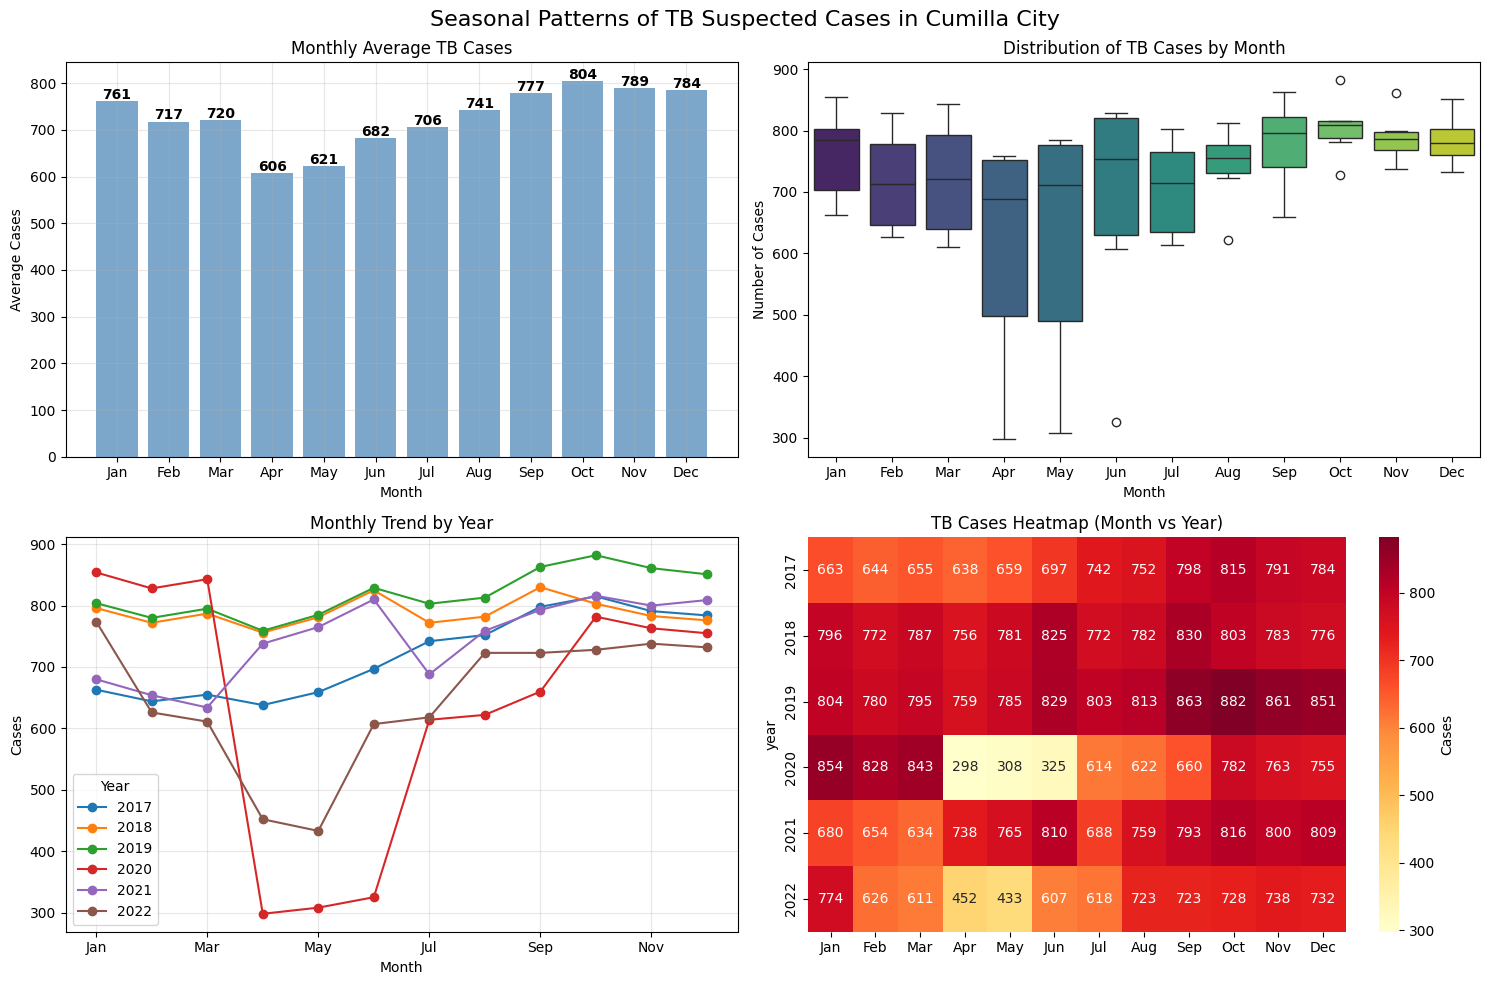

In [7]:
# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Seasonal Patterns of TB Suspected Cases in Cumilla City', fontsize=16)

# Plot 1: Bar chart of monthly averages
ax1 = axes[0, 0]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax1.bar(months, monthly_avg['mean'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Cases')
ax1.set_title('Monthly Average TB Cases')
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(monthly_avg['mean']):
    ax1.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')

# Plot 2: Boxplot by month (shows distribution)
ax2 = axes[0, 1]
# Create month order
month_order = sorted(df['month'].unique())
month_names = [pd.Timestamp(2023, m, 1).strftime('%b') for m in month_order]
sns.boxplot(x='month', y='total_count', data=df, ax=ax2, palette='viridis')
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Cases')
ax2.set_title('Distribution of TB Cases by Month')
ax2.set_xticklabels(month_names)

# Plot 3: Line plot showing trend across months (each year as separate line)
ax3 = axes[1, 0]
pivot_data = df.pivot_table(values='total_count', index='month', columns='year', aggfunc='mean')
pivot_data.index = month_names
pivot_data.plot(marker='o', ax=ax3)
ax3.set_xlabel('Month')
ax3.set_ylabel('Cases')
ax3.set_title('Monthly Trend by Year')
ax3.grid(True, alpha=0.3)
ax3.legend(title='Year')

# Plot 4: Heatmap of monthly patterns
ax4 = axes[1, 1]
# Create month-year pivot for heatmap
heatmap_data = df.pivot_table(values='total_count', index='year', columns='month', aggfunc='mean')
heatmap_data.columns = month_names
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax4, 
            cbar_kws={'label': 'Cases'})
ax4.set_title('TB Cases Heatmap (Month vs Year)')

plt.tight_layout()
plt.show()

In [8]:
from scipy import stats

# 1. One-way ANOVA to test if monthly differences are significant
monthly_groups = [df[df['month'] == m]['total_count'].values for m in range(1, 13)]
f_stat, p_value = stats.f_oneway(*monthly_groups)

print("\n" + "=" * 60)
print("STATISTICAL TESTS FOR SEASONALITY")
print("=" * 60)
print(f"ANOVA test - Is there significant difference between months?")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("✅ RESULT: Significant seasonal pattern detected (p < 0.05)")
else:
    print("❌ RESULT: No significant seasonal pattern detected (p >= 0.05)")

# 2. Identify seasonal peaks and troughs
print("\n" + "-" * 40)
print("SEASONAL PATTERN SUMMARY")
print("-" * 40)

# Sort months by average cases
ranked_months = monthly_avg['mean'].sort_values(ascending=False)
print("\n📊 Months ranked by average cases (highest to lowest):")
for i, (month, value) in enumerate(ranked_months.items(), 1):
    print(f"{i:2d}. {month}: {value:.1f} cases")

# Group into seasons
def get_season(month_num):
    if month_num in [12, 1, 2]:
        return 'Winter'
    elif month_num in [3, 4, 5]:
        return 'Spring'
    elif month_num in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(get_season)

# Seasonal averages
seasonal_avg = df.groupby('season')['total_count'].agg(['mean', 'std']).round(2)
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_avg = seasonal_avg.reindex(season_order)

print("\n🌍 AVERAGE BY SEASON:")
print(seasonal_avg)

# Find which season has highest/lowest
peak_season = seasonal_avg['mean'].idxmax()
low_season = seasonal_avg['mean'].idxmin()
print(f"\n🔥 Peak season: {peak_season} ({seasonal_avg.loc[peak_season, 'mean']} cases)")
print(f"❄️ Lowest season: {low_season} ({seasonal_avg.loc[low_season, 'mean']} cases)")


STATISTICAL TESTS FOR SEASONALITY
ANOVA test - Is there significant difference between months?
F-statistic: 1.8350
P-value: 0.0677
❌ RESULT: No significant seasonal pattern detected (p >= 0.05)

----------------------------------------
SEASONAL PATTERN SUMMARY
----------------------------------------

📊 Months ranked by average cases (highest to lowest):
 1. Oct: 804.3 cases
 2. Nov: 789.3 cases
 3. Dec: 784.5 cases
 4. Sep: 777.8 cases
 5. Jan: 761.8 cases
 6. Aug: 741.8 cases
 7. Mar: 720.8 cases
 8. Feb: 717.3 cases
 9. Jul: 706.2 cases
10. Jun: 682.2 cases
11. May: 621.8 cases
12. Apr: 606.8 cases

🌍 AVERAGE BY SEASON:
          mean     std
season                
Winter  754.56   71.82
Spring  649.83  169.03
Summer  710.06  122.70
Fall    790.50   54.69

🔥 Peak season: Fall (790.5 cases)
❄️ Lowest season: Spring (649.83 cases)


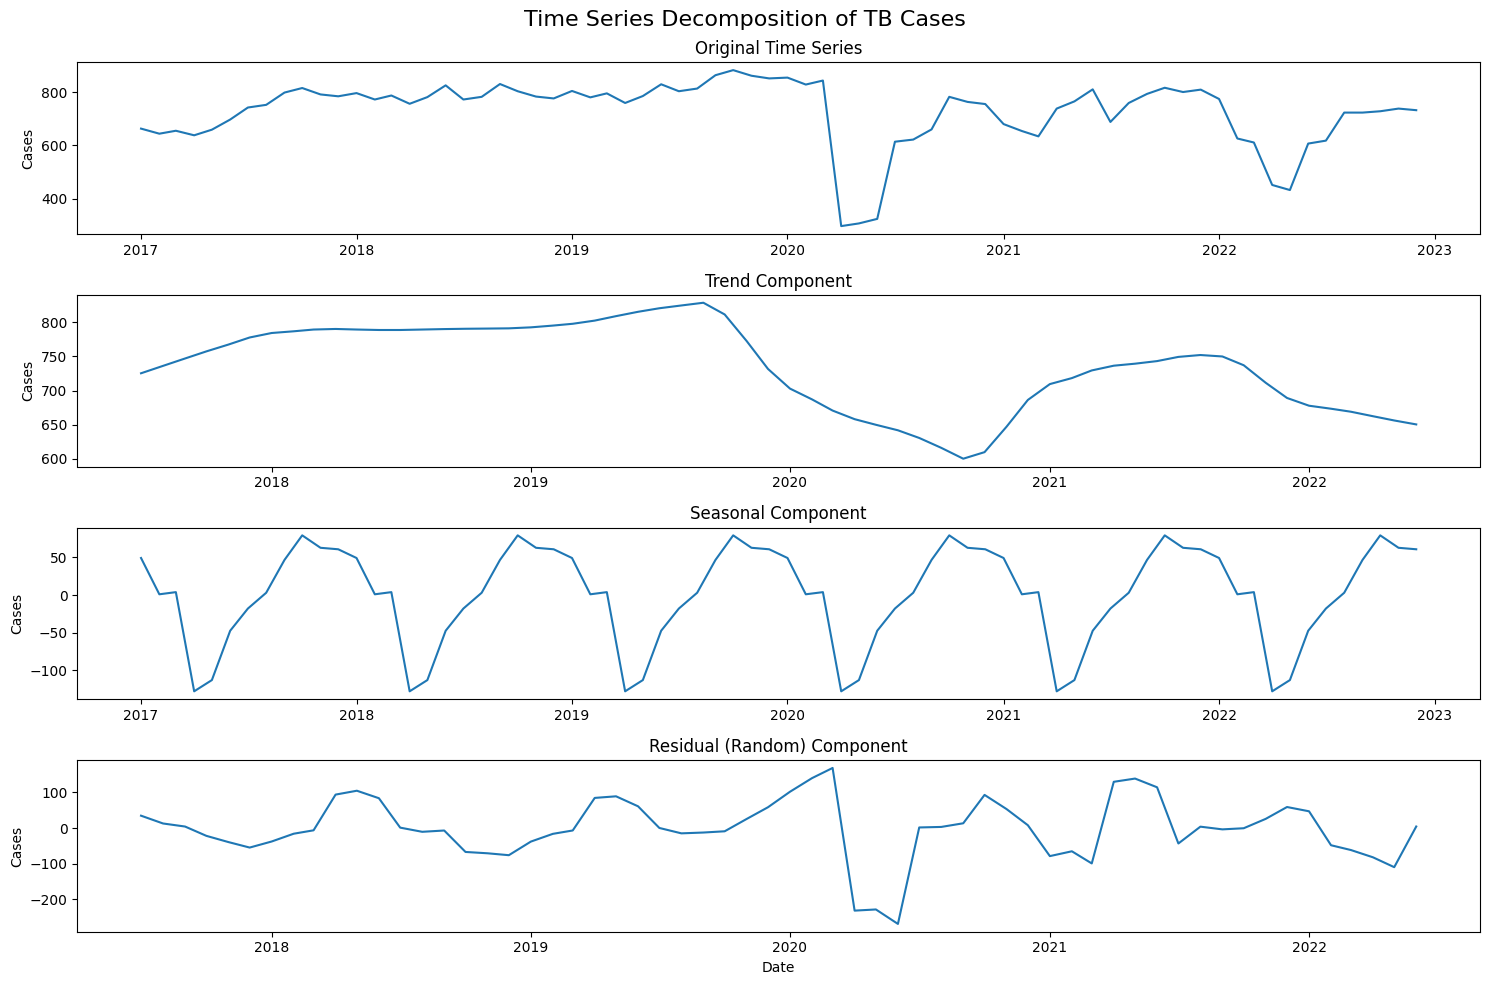


📅 MONTHLY SEASONAL FACTORS:
Jan: +49.29 cases ⬆️ Above average
Feb: +0.97 cases ⬆️ Above average
Mar: +3.83 cases ⬆️ Above average
Apr: -128.22 cases ⬇️ Below average
May: -113.25 cases ⬇️ Below average
Jun: -47.57 cases ⬇️ Below average
Jul: -18.02 cases ⬇️ Below average
Aug: +3.01 cases ⬆️ Above average
Sep: +46.73 cases ⬆️ Above average
Oct: +79.44 cases ⬆️ Above average
Nov: +62.88 cases ⬆️ Above average
Dec: +60.91 cases ⬆️ Above average


In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set time as index for decomposition
df_ts = df.set_index('time')
df_ts = df_ts.sort_index()

# Perform seasonal decomposition (assuming monthly data)
# Need at least 2 full cycles (24 months) for this
if len(df_ts) >= 24:
    decomposition = seasonal_decompose(df_ts['total_count'], model='additive', period=12)
    
    fig, axes = plt.subplots(4, 1, figsize=(15, 10))
    fig.suptitle('Time Series Decomposition of TB Cases', fontsize=16)
    
    # Original
    axes[0].plot(df_ts.index, df_ts['total_count'])
    axes[0].set_title('Original Time Series')
    axes[0].set_ylabel('Cases')
    
    # Trend
    axes[1].plot(df_ts.index, decomposition.trend)
    axes[1].set_title('Trend Component')
    axes[1].set_ylabel('Cases')
    
    # Seasonal
    axes[2].plot(df_ts.index, decomposition.seasonal)
    axes[2].set_title('Seasonal Component')
    axes[2].set_ylabel('Cases')
    
    # Residual
    axes[3].plot(df_ts.index, decomposition.resid)
    axes[3].set_title('Residual (Random) Component')
    axes[3].set_ylabel('Cases')
    axes[3].set_xlabel('Date')
    
    plt.tight_layout()
    plt.show()
    
    # Print seasonal factors
    seasonal_factors = decomposition.seasonal[:12].values
    print("\n📅 MONTHLY SEASONAL FACTORS:")
    for month, factor in zip(month_names, seasonal_factors):
        direction = "⬆️ Above average" if factor > 0 else "⬇️ Below average"
        print(f"{month}: {factor:+.2f} cases {direction}")
else:
    print("\n⚠️ Need at least 24 months of data for seasonal decomposition")
    print(f"Current data has {len(df_ts)} months")

In [10]:
# Generate a comprehensive summary
print("\n" + "=" * 70)
print("📋 SEASONAL ANALYSIS SUMMARY REPORT")
print("=" * 70)

print(f"\n📅 Data Period: {df['time'].min().date()} to {df['time'].max().date()}")
print(f"📊 Total Months: {len(df)}")
print(f"👥 Total Cases: {df['total_count'].sum():,}")
print(f"📈 Monthly Average: {df['total_count'].mean():.1f} ± {df['total_count'].std():.1f}")

print("\n" + "-" * 40)
print("SEASONAL HIGHLIGHTS")
print("-" * 40)

# Peak and low months
peak_data = df[df['month'] == (monthly_avg['mean'].idxmax())]
low_data = df[df['month'] == (monthly_avg['mean'].idxmin())]

print(f"\n🏆 PEAK SEASON ({peak_month}):")
print(f"   Average: {monthly_avg.loc[peak_month, 'mean']:.1f} cases")
print(f"   Range: {monthly_avg.loc[peak_month, 'min']:.0f} - {monthly_avg.loc[peak_month, 'max']:.0f} cases")
print(f"   % above average: {((monthly_avg.loc[peak_month, 'mean']/df['total_count'].mean() - 1)*100):+.1f}%")

print(f"\n📉 LOW SEASON ({low_month}):")
print(f"   Average: {monthly_avg.loc[low_month, 'mean']:.1f} cases")
print(f"   Range: {monthly_avg.loc[low_month, 'min']:.0f} - {monthly_avg.loc[low_month, 'max']:.0f} cases")
print(f"   % above average: {((monthly_avg.loc[low_month, 'mean']/df['total_count'].mean() - 1)*100):+.1f}%")

print("\n" + "-" * 40)
print("KEY FINDINGS")
print("-" * 40)
print("✓ The seasonal pattern shows", end=" ")
if p_value < 0.05:
    print("statistically significant variation across months.")
else:
    print("no statistically significant variation across months.")
    
print(f"✓ {peak_month} has the highest TB cases, {low_month} has the lowest.")
print(f"✓ The difference between peak and low season is {monthly_avg['mean'].max() - monthly_avg['mean'].min():.1f} cases.")
print(f"✓ {peak_season} appears to be the peak season overall.")


📋 SEASONAL ANALYSIS SUMMARY REPORT

📅 Data Period: 2017-01-01 to 2022-12-01
📊 Total Months: 72
👥 Total Cases: 52,289
📈 Monthly Average: 726.2 ± 123.3

----------------------------------------
SEASONAL HIGHLIGHTS
----------------------------------------

🏆 PEAK SEASON (Oct):
   Average: 804.3 cases
   Range: 728 - 882 cases
   % above average: +10.8%

📉 LOW SEASON (Apr):
   Average: 606.8 cases
   Range: 298 - 759 cases
   % above average: -16.4%

----------------------------------------
KEY FINDINGS
----------------------------------------
✓ The seasonal pattern shows no statistically significant variation across months.
✓ Oct has the highest TB cases, Apr has the lowest.
✓ The difference between peak and low season is 197.5 cases.
✓ Fall appears to be the peak season overall.


In [11]:
# Save monthly statistics to CSV
monthly_avg.to_csv('monthly_tb_statistics.csv')
print("\n✅ Monthly statistics saved to 'monthly_tb_statistics.csv'")

# Save the plots
plt.figure(1)  # The main figure with all plots
plt.savefig('seasonal_analysis_full.png', dpi=300, bbox_inches='tight')
print("✅ Plots saved to 'seasonal_analysis_full.png'")


✅ Monthly statistics saved to 'monthly_tb_statistics.csv'
✅ Plots saved to 'seasonal_analysis_full.png'


<Figure size 640x480 with 0 Axes>

In [12]:
# Check April across years
april_data = df[df['month'] == 4]
print(april_data[['time', 'total_count', 'rainfall_mm', 'max_temp_cel']])

         time  total_count  rainfall_mm  max_temp_cel
3  2017-04-01          638          361         30.84
15 2018-04-01          756          214         31.95
27 2019-04-01          759          238         32.64
39 2020-04-01          298          215         32.10
51 2021-04-01          738            3         34.63
63 2022-04-01          452           53         32.93


        total_count  rainfall_mm  max_temp_cel  humidity_percent
season                                                          
Fall     790.500000   156.388889     31.729444         81.552222
Spring   649.833333   166.833333     32.292222         77.182222
Summer   710.055556   355.944444     32.123889         84.447778
Winter   754.555556    30.222222     26.607778         76.164444


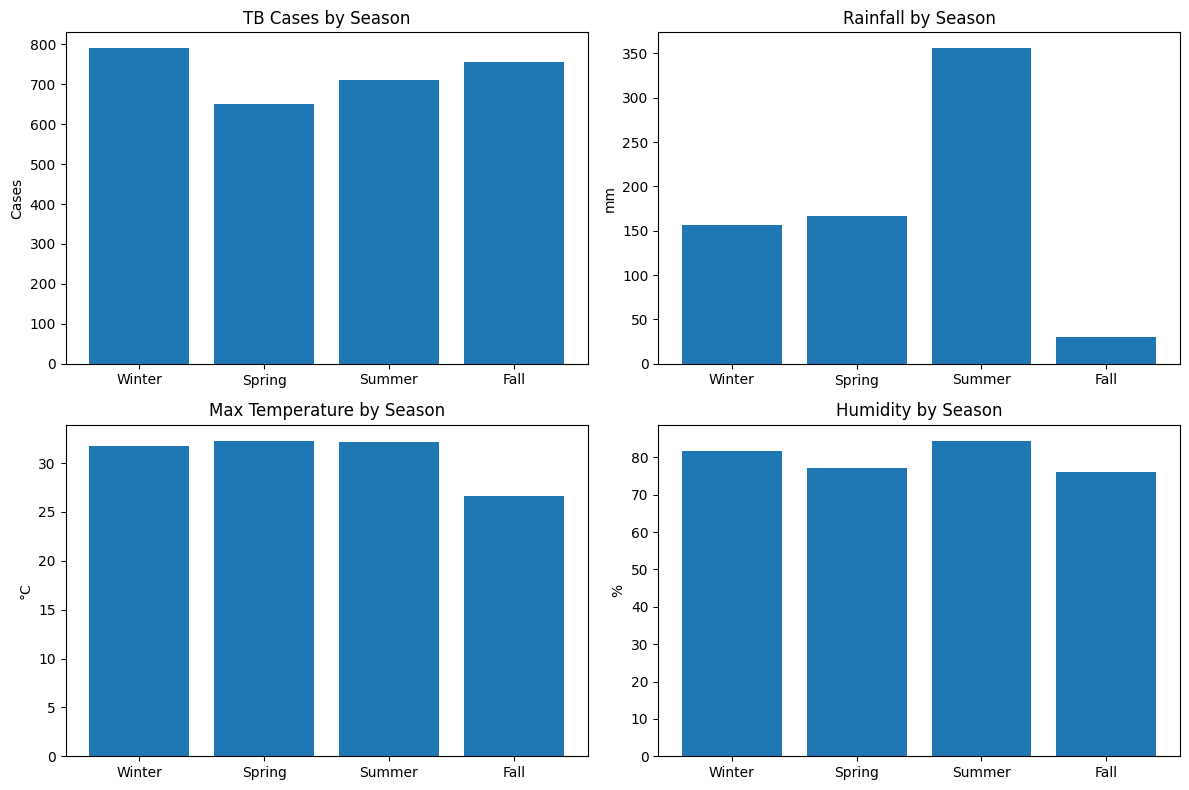

In [13]:
# Create a seasonal analysis with climate
seasonal_climate = df.groupby('season')[['total_count', 
                                         'rainfall_mm', 
                                         'max_temp_cel',
                                         'humidity_percent']].mean()

print(seasonal_climate)

# Plot seasonal climate vs TB cases
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
seasons = ['Winter', 'Spring', 'Summer', 'Fall']

# TB Cases
axes[0,0].bar(seasons, seasonal_climate['total_count'])
axes[0,0].set_title('TB Cases by Season')
axes[0,0].set_ylabel('Cases')

# Rainfall
axes[0,1].bar(seasons, seasonal_climate['rainfall_mm'])
axes[0,1].set_title('Rainfall by Season')
axes[0,1].set_ylabel('mm')

# Temperature
axes[1,0].bar(seasons, seasonal_climate['max_temp_cel'])
axes[1,0].set_title('Max Temperature by Season')
axes[1,0].set_ylabel('°C')

# Humidity
axes[1,1].bar(seasons, seasonal_climate['humidity_percent'])
axes[1,1].set_title('Humidity by Season')
axes[1,1].set_ylabel('%')

plt.tight_layout()
plt.show()

In [14]:
# Calculate correlations with different lags
for lag in [0, 1, 2, 3]:
    df[f'rainfall_lag_{lag}'] = df['rainfall_mm'].shift(lag)
    
lag_correlations = []
for lag in range(0, 4):
    corr = df[f'rainfall_lag_{lag}'].corr(df['total_count'])
    lag_correlations.append(corr)
    print(f"Lag {lag} months: {corr:.3f}")

Lag 0 months: -0.192
Lag 1 months: 0.055
Lag 2 months: 0.215
Lag 3 months: 0.352
